In [13]:
!pip install matplotlib
import pandas as pd
import matplotlib.pyplot as plt

Defaulting to user installation because normal site-packages is not writeable



[notice] A new release of pip is available: 26.0.1 -> 26.1.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [14]:
df = pd.read_csv('student_performance.csv')

Importing SQLite3

In [15]:
import sqlite3

In [16]:
#creating a connection to the database
conn = sqlite3.connect('student_performance.db')
cursor = conn.cursor()
# df.to_sql('students',conn,if_exists='replace',index=False)
cursor.execute("SELECT COUNT(*) FROM students")

The below function helps to run the SELECT queries with the conn in pandas library if you don't need this you can even use the cursor.execute()

In [17]:
def run_query(sql,description=""):
  if description:
    print(f"\n{'='*55}")
    print(f"{description}")
    print(f"{'='*55}")
  result = pd.read_sql_query(sql,conn)
  print(result.to_string(index=False))
  return result

Panel 1 data: avg math by department

In [18]:
query1 = """SELECT Department,AVG(math_score) 
            AS avg_math FROM 
            students GROUP BY 
            department;"""
panel1 = run_query(query1,"Average math score by dept")


Average math score by dept
      department  avg_math
           Civil 63.400000
Computer Science 85.615385
     Electronics 71.000000
      Mechanical 71.000000


Panel 2 data: student count by department

In [19]:
query2 = """SELECT Department,COUNT(*) 
            AS student_count 
            FROM students 
            GROUP BY department;"""
panel2 = run_query(query2,"Student count by dept")


Student count by dept
      department  student_count
           Civil              5
Computer Science             13
     Electronics              6
      Mechanical              6


Panel 3 data: top 8 students by total score


In [20]:
query3 = """SELECT Name, 
            (math_score + science_score + english_score + programming_score ) 
            AS total_score 
            FROM students 
            ORDER BY total_score DESC 
            LIMIT 8;"""
panel3 = run_query(query3,"Top 8 students by total score")


Top 8 students by total score
          name  total_score
    Ananya Das          371
   Tanvi Mehta          367
Akanksha Yadav          365
    Arjun Nair          356
   Divya Singh          356
Swati Kulkarni          354
     Amit Bose          336
    Suresh Rao          334


Panel 4 data: gender-wise average attendance


In [21]:
query4 = """SELECT gender,
            AVG(attendance_percentage) AS avg_attendance
            FROM students 
            GROUP BY gender;"""
panel4 = run_query(query4,"Gender-wise average attendance")


Gender-wise average attendance
gender  avg_attendance
Female       88.533333
  Male       80.466667


Matplotlib
- Panel 1 (top-left): Avg Math by Department - BAR Chart
- Panel 2 (top-right): Student Count Pie Chart
- Panel 3 (bottom-left): Top 8 Students Horizontal Bar
- Panel 4 (bottom-right): Gender Avg Attendance Bar

DONE BY OWN

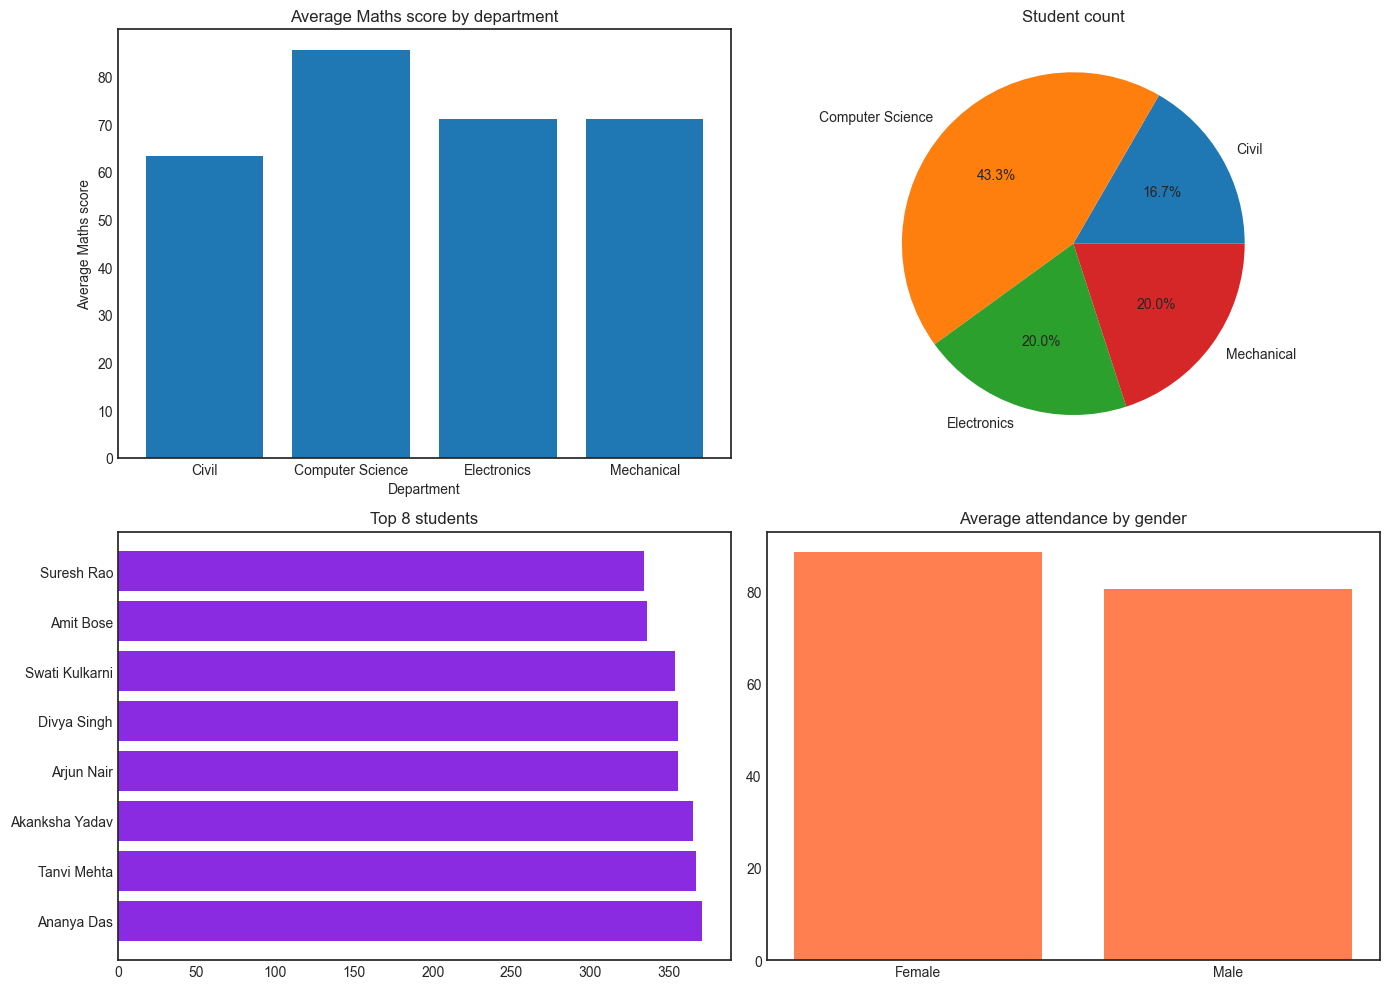

In [22]:
fig, ax = plt.subplots(2, 2, figsize=(14, 10))
#panel 1 on top left
ax[0,0].bar(panel1['department'],panel1['avg_math'])
ax[0,0].set_xlabel('Department')
ax[0,0].set_ylabel('Average Maths score')
ax[0,0].set_title('Average Maths score by department')
#panel 2 on top right
ax[0,1].pie(panel2['student_count'],labels=panel2['department'],autopct = "%1.1f%%")
ax[0,1].set_title('Student count')
#panel 3 on bottom left
ax[1,0].barh(panel3['name'],panel3['total_score'],color='blueviolet')
ax[1,0].set_title('Top 8 students')
#panel 4 on bottom right
ax[1,1].bar(panel4['gender'],panel4['avg_attendance'],color='coral')
ax[1,1].set_title('Average attendance by gender')
plt.tight_layout()
plt.show()

Done by with help of AI 

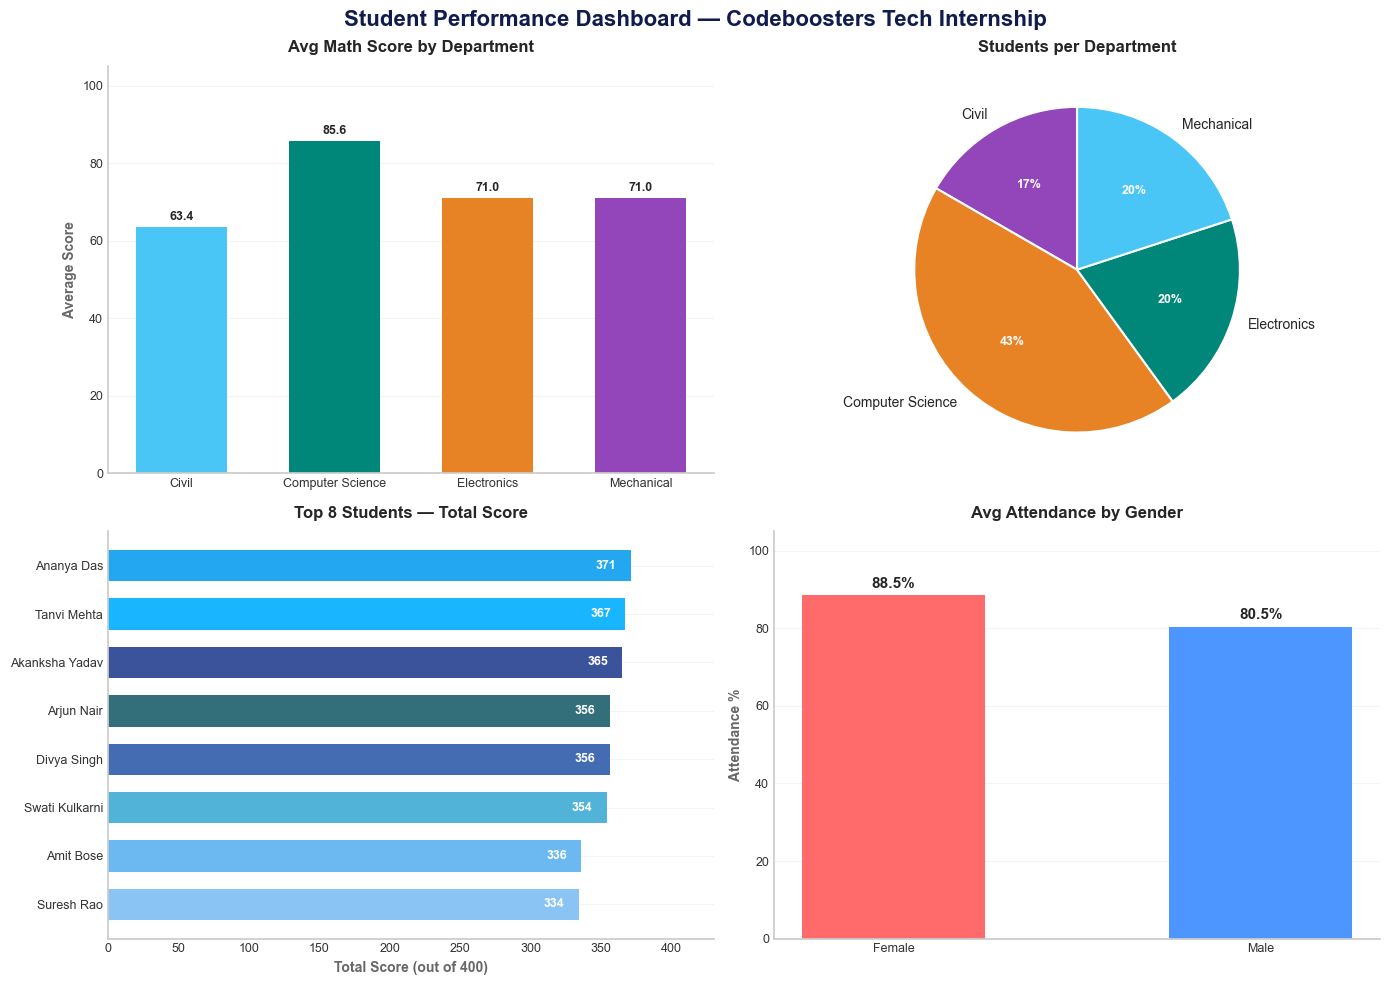

In [23]:
import matplotlib.pyplot as plt

# 1. Set a clean, modern aesthetic style
plt.style.use('seaborn-v0_8-white' if 'seaborn-v0_8-white' in plt.style.available else 'default')

# 2. Define distinct color palettes for variation
PALETTE_PASTEL_TECH = ['#49C5F6', '#008779', '#E78325', '#9246B9'] # Blue, Teal, Orange, Purple
PALETTE_GRADIENT_BLUE = ['#22A7F0', '#19B5FE', '#3A539B', '#336E7B', '#446CB3', '#52B3D9', '#6BB9F0', '#89C4F4'] # Custom blues/teals for ranks
GENDER_COLORS = ['#FF6B6B', '#4D96FF'] # Coral Pink and Vibrant Blue

fig, ax = plt.subplots(2, 2, figsize=(14, 10))

# Add the main dashboard title at the very top
fig.suptitle('Student Performance Dashboard — Codeboosters Tech Internship', 
             fontsize=16, fontweight='bold', color='#111C4E', y=0.98)

# ── panel 1 on top left: Multi-colored bars ──
bars1 = ax[0,0].bar(panel1['department'], panel1['avg_math'], color=PALETTE_PASTEL_TECH, width=0.6)
ax[0,0].set_ylabel('Average Score', fontweight='bold', alpha=0.7)
ax[0,0].set_title('Avg Math Score by Department', fontweight='bold', pad=10)
ax[0,0].set_ylim(0, 105)
ax[0,0].bar_label(bars1, fmt='%.1f', padding=3, fontweight='bold', size=9)

# ── panel 2 on top right: Distinct pie slices ──
wedges, texts, autotexts = ax[0,1].pie(
    panel2['student_count'], 
    labels=panel2['department'], 
    autopct="%1.0f%%", 
    startangle=90, 
    colors=PALETTE_PASTEL_TECH[::-1], # Reversed palette order for visual distinction
    wedgeprops={'edgecolor': 'white', 'linewidth': 1.5}
)
ax[0,1].set_title('Students per Department', fontweight='bold', pad=10)
plt.setp(autotexts, size=9, weight='bold', color='white') # Crisp white text inside slices

# ── panel 3 on bottom left: Ranked gradient horizontal bars ──
bars3 = ax[1,0].barh(panel3['name'], panel3['total_score'], color=PALETTE_GRADIENT_BLUE, height=0.65)
ax[1,0].set_xlabel('Total Score (out of 400)', fontweight='bold', alpha=0.7)
ax[1,0].set_title('Top 8 Students — Total Score', fontweight='bold', pad=10)
ax[1,0].set_xlim(0, 430)
ax[1,0].invert_yaxis() # Top student remains at the top
ax[1,0].bar_label(bars3, fmt='%d', padding=-25, color='white', fontweight='bold', size=9)

# ── panel 4 on bottom right: Gender-coded bars ──
bars4 = ax[1,1].bar(panel4['gender'], panel4['avg_attendance'], color=GENDER_COLORS, width=0.5)
ax[1,1].set_ylabel('Attendance %', fontweight='bold', alpha=0.7)
ax[1,1].set_title('Avg Attendance by Gender', fontweight='bold', pad=10)
ax[1,1].set_ylim(0, 105)
ax[1,1].bar_label(bars4, fmt='%.1f%%', padding=3, fontweight='bold', size=11)

# 3. Clean up the borders (spines) and layout for all charts
for row in ax:
    for sub_ax in row:
        # Subtle horizontal grid lines behind bar charts
        if sub_ax != ax[0,1]: 
            sub_ax.grid(axis='y', linestyle='-', alpha=0.2, color='#CCCCCC')
            sub_ax.set_axisbelow(True) # Keeps grid lines behind the data bars
        
        # Hide top and right bounding box lines
        sub_ax.spines['top'].set_visible(False)
        sub_ax.spines['right'].set_visible(False)
        sub_ax.spines['left'].set_color('#CCCCCC')
        sub_ax.spines['bottom'].set_color('#CCCCCC')
        sub_ax.tick_params(labelsize=9, labelcolor='#333333')

plt.tight_layout()
plt.show()
